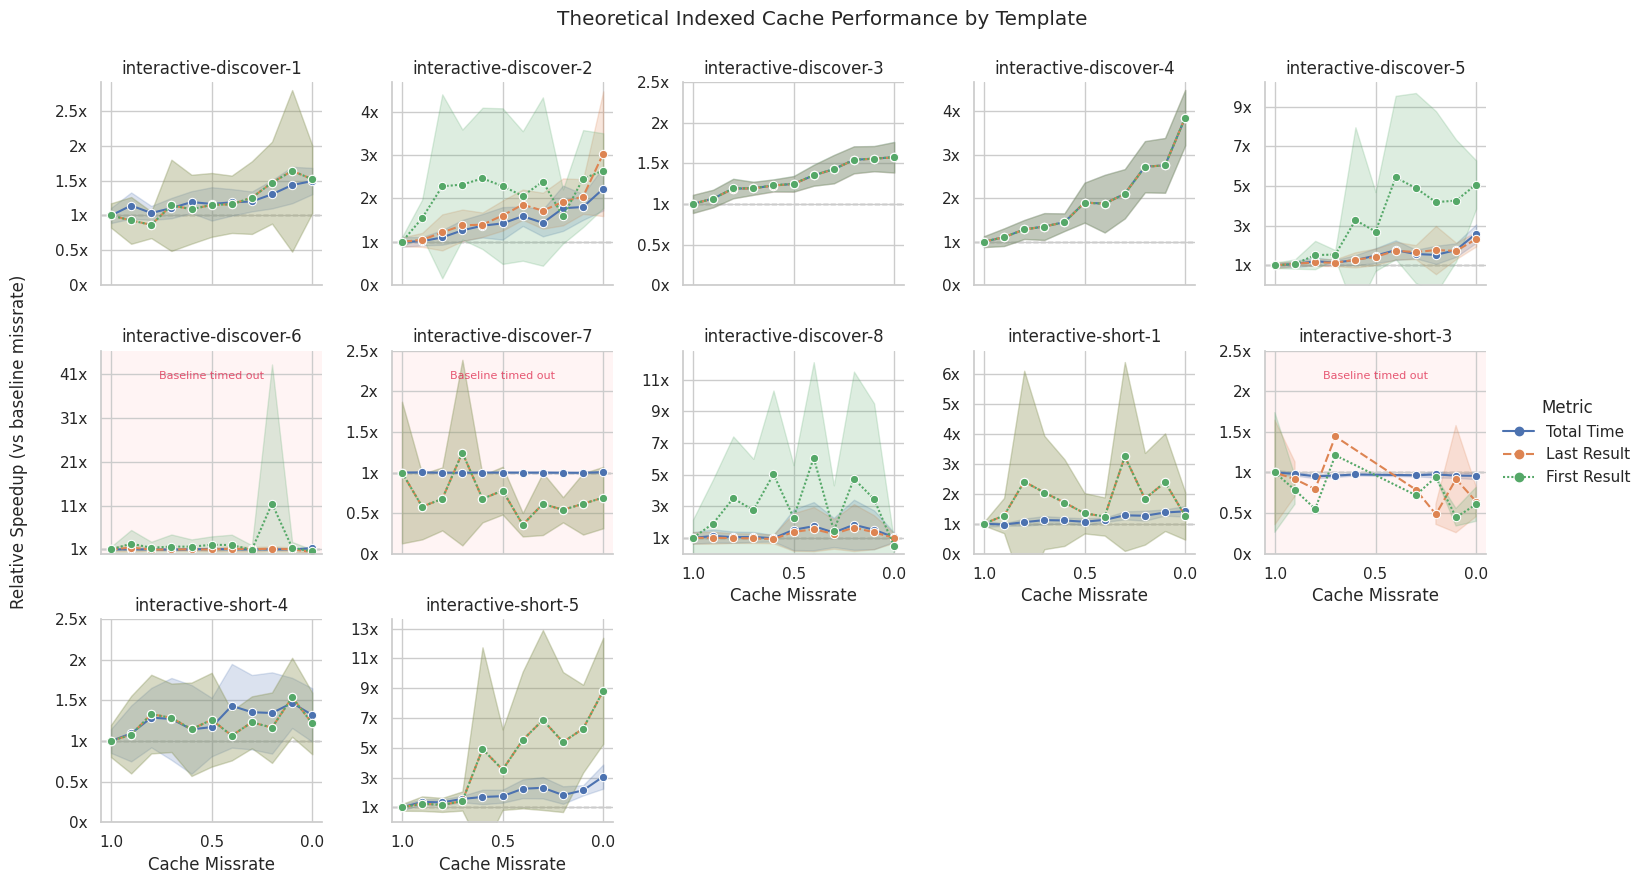

In [2]:
from matplotlib import ticker
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import json
import glob
import re
import os
import numpy as np


def load_and_process_data(directory, file_pattern="query-results-raw-hitrate-*.json"):
    data = []

    # 1. Load Data
    for filepath in glob.glob(os.path.join(directory, file_pattern)):
        match = re.search(r'hitrate-([0-9.]+)', filepath)
        if not match:
            continue
        missrate = float(match.group(1)[:-1])

        with open(filepath, 'r') as f:
            results = json.load(f)

        for row in results:
            name = row.get("name", "")
            time = row.get("time")
            error = bool(row.get("error", False))

            timestamps = row.get("timestamps", [])
            num_timestamps = len(timestamps)
            time_first = timestamps[0] if num_timestamps > 0 else pd.NA
            time_last = timestamps[-1] if num_timestamps > 0 else pd.NA
            has_results = num_timestamps > 0

            run_id = str(row.get("id"))
            is_first = run_id == "0"
            is_repeat = run_id == "1"

            if not (is_first or is_repeat):
                continue

            template_name = name.replace("repeat_", "")

            data.append({
                "missrate": missrate,
                "template": template_name,
                "is_repeat": is_repeat,
                "time": time,
                "time_first": time_first,
                "time_last": time_last,
                "num_timestamps": num_timestamps,
                "error": error,
                "has_results": has_results
            })

    df = pd.DataFrame(data)

    # Assign a repetition index within each (missrate, template, is_repeat) group
    df['repetition'] = df.groupby(['missrate', 'template', 'is_repeat']).cumcount()

    # 2. Separate First and Repeat Runs
    first_runs = df[~df['is_repeat']].copy()
    first_runs.columns = [
        f"{col}_first" if col not in ['missrate', 'template', 'repetition'] else col
        for col in first_runs.columns
    ]

    repeat_runs = df[df['is_repeat']].copy()
    repeat_runs.columns = [
        f"{col}_repeat" if col not in ['missrate', 'template', 'repetition'] else col
        for col in repeat_runs.columns
    ]

    merged = pd.merge(first_runs, repeat_runs, on=['missrate', 'template', 'repetition'])

    # Keep only rows where both runs are valid (no error, or error but had partial results)
    valid_first = ~merged['error_first'] | (merged['error_first'] & merged['has_results_first'])
    valid_repeat = ~merged['error_repeat'] | (merged['error_repeat'] & merged['has_results_repeat'])
    valid_runs = merged[valid_first & valid_repeat].copy()

    # 3. Per-repetition speedup
    valid_runs['speedup_total'] = (
        valid_runs['time_first'] / valid_runs['time_repeat']
    )

    valid_runs['speedup_first_result'] = (
        valid_runs['time_first_first'] / valid_runs['time_first_repeat']
    )
    valid_runs['speedup_last_result'] = (
        valid_runs['time_last_first'] / valid_runs['time_last_repeat']
    )

    # Invalidate first/last-result speedups where the number of result rows differs
    valid_timestamp_match = (
        valid_runs['num_timestamps_first'] == valid_runs['num_timestamps_repeat']
    )
    valid_runs.loc[~valid_timestamp_match, ['speedup_first_result', 'speedup_last_result']] = pd.NA

    # 4. Compute baseline mean speedup per template
    BASELINE_MISSRATE = 1.0

    baseline = valid_runs[valid_runs['missrate'] == BASELINE_MISSRATE].copy()

    # Identify templates that timed out at the baseline
    timeout_mask = baseline['error_first'] | baseline['error_repeat']
    timeout_templates = set(baseline.loc[timeout_mask, 'template'].unique())

    baseline_agg = baseline.groupby('template').agg(
        speedup_total_baseline=('speedup_total', 'mean'),
        speedup_first_baseline=('speedup_first_result', 'mean'),
        speedup_last_baseline=('speedup_last_result', 'mean'),
    ).reset_index()

    valid_runs = pd.merge(valid_runs, baseline_agg, on='template')

    # Tag the template names to update the facet titles
    valid_runs['template'] = valid_runs['template'].apply(
        lambda x: f"{x} (Timeout Baseline)" if x in timeout_templates else x
    )

    # 5. Relative speedup per repetition (normalised to baseline mean)
    valid_runs['Total Time'] = (
        valid_runs['speedup_total'] / valid_runs['speedup_total_baseline']
    )
    valid_runs['First Result'] = (
        valid_runs['speedup_first_result'] / valid_runs['speedup_first_baseline']
    )
    valid_runs['Last Result'] = (
        valid_runs['speedup_last_result'] / valid_runs['speedup_last_baseline']
    )

    # 6. Melt to long form for seaborn
    melted_df = valid_runs.melt(
        id_vars=['missrate', 'template', 'repetition'],
        value_vars=['Total Time', 'First Result', 'Last Result'],
        var_name='Metric',
        value_name='Speedup'
    )

    melted_df = melted_df.dropna(subset=['Speedup'])

    valid_counts = melted_df.groupby('template').size()
    active_templates = valid_counts[valid_counts > 0].index
    final_df = melted_df[melted_df['template'].isin(active_templates)]
    final_df = final_df.sort_values('template')

    return final_df


def create_trellis_plot(df):
    sns.set_theme(style="whitegrid")

    g = sns.relplot(
        data=df,
        x="missrate",
        y="Speedup",
        hue="Metric",
        style="Metric",
        col="template",
        col_wrap=5,
        kind="line",
        marker="o",
        errorbar="sd",  # Revert to standard deviation to restore missing bands
        height=3,
        aspect=1,
        facet_kws={'sharey': False, 'sharex': True}
    )

    # Invert X axis to range from 1 to 0
    g.set(xlim=(1.05, -0.05))
    g.set_axis_labels("Cache Missrate", "")
    g.set_titles(col_template="{col_name}")

    for ax in g.axes.flat:
        title = ax.get_title()

        # Handle timeout visuals
        if "(Timeout Baseline)" in title:
            ax.set_title(title.replace(" (Timeout Baseline)", ""))
            ax.set_facecolor('#fff4f4')
            ax.text(0.5, 0.9, "Baseline timed out",
                    transform=ax.transAxes, ha='center', va='top',
                    fontsize=8, color='crimson', alpha=0.7)

        # Draw a horizontal baseline at y=1.0
        ax.axhline(1.0, color='gray', linestyle='--', linewidth=1, zorder=0)

        # 1. Cap bottom at 0 to clip negative standard deviation shading
        # 2. Enforce minimum top limit of 2.5 so the 1.0 baseline is never above the midline
        ylim = ax.get_ylim()
        new_top = max(ylim[1], 2.5)
        ax.set_ylim(bottom=0, top=new_top)

        # Anchor ticks to 1.0 using the automatically calculated step size
        ylim = ax.get_ylim()
        ticks = ax.get_yticks()

        if len(ticks) > 1:
            step = ticks[1] - ticks[0]
            if step > 0:
                # Calculate grid boundaries to ensure full coverage of the current y-limits
                min_tick = 1.0 - np.ceil((1.0 - ylim[0]) / step) * step
                max_tick = 1.0 + np.ceil((ylim[1] - 1.0) / step) * step

                new_ticks = np.arange(min_tick, max_tick + step / 2, step)

                # Remove any negative ticks generated by the step sequence
                new_ticks = new_ticks[new_ticks >= 0]
                ax.set_yticks(new_ticks)

        # Restore upper limits to prevent the new ticks from expanding the axis
        ax.set_ylim(bottom=0, top=ylim[1])

        # Format y-ticks as multipliers (e.g., 1.5x)
        ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: f'{y:g}x'))

    g.figure.suptitle("Theoretical Indexed Cache Performance by Template")
    g.figure.subplots_adjust(top=0.9, left=0.06)
    g.figure.text(0.01, 0.5, "Relative Speedup (vs baseline missrate)",
               va='center', ha='center', rotation='vertical', fontsize=12)

    plt.savefig("cache_performance_trellis.png", dpi=300, bbox_inches='tight')
    plt.show()


if __name__ == "__main__":
    df_results = load_and_process_data("../data/data-synth-hitrate")
    if not df_results.empty:
        create_trellis_plot(df_results)
    else:
        print("No valid data found after filtering errors.")

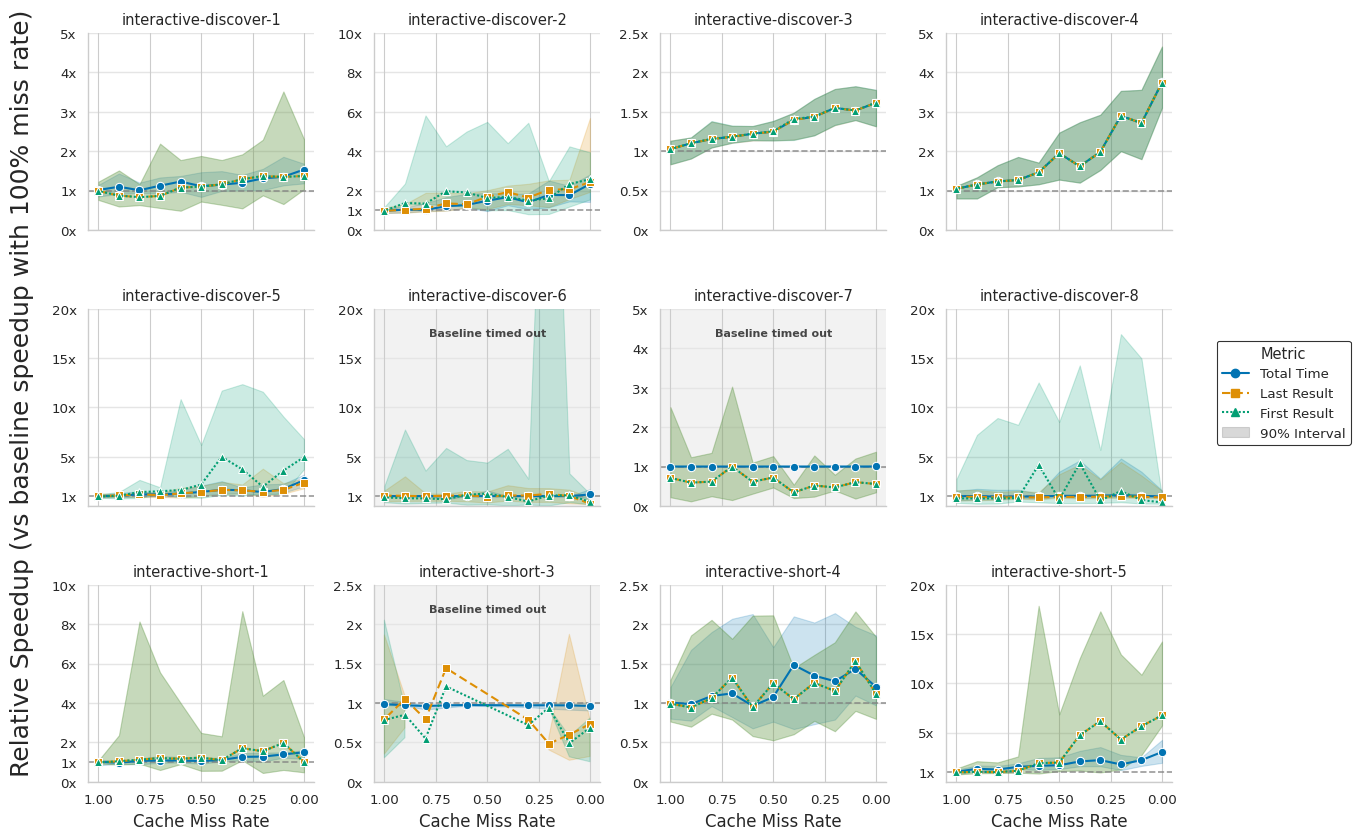

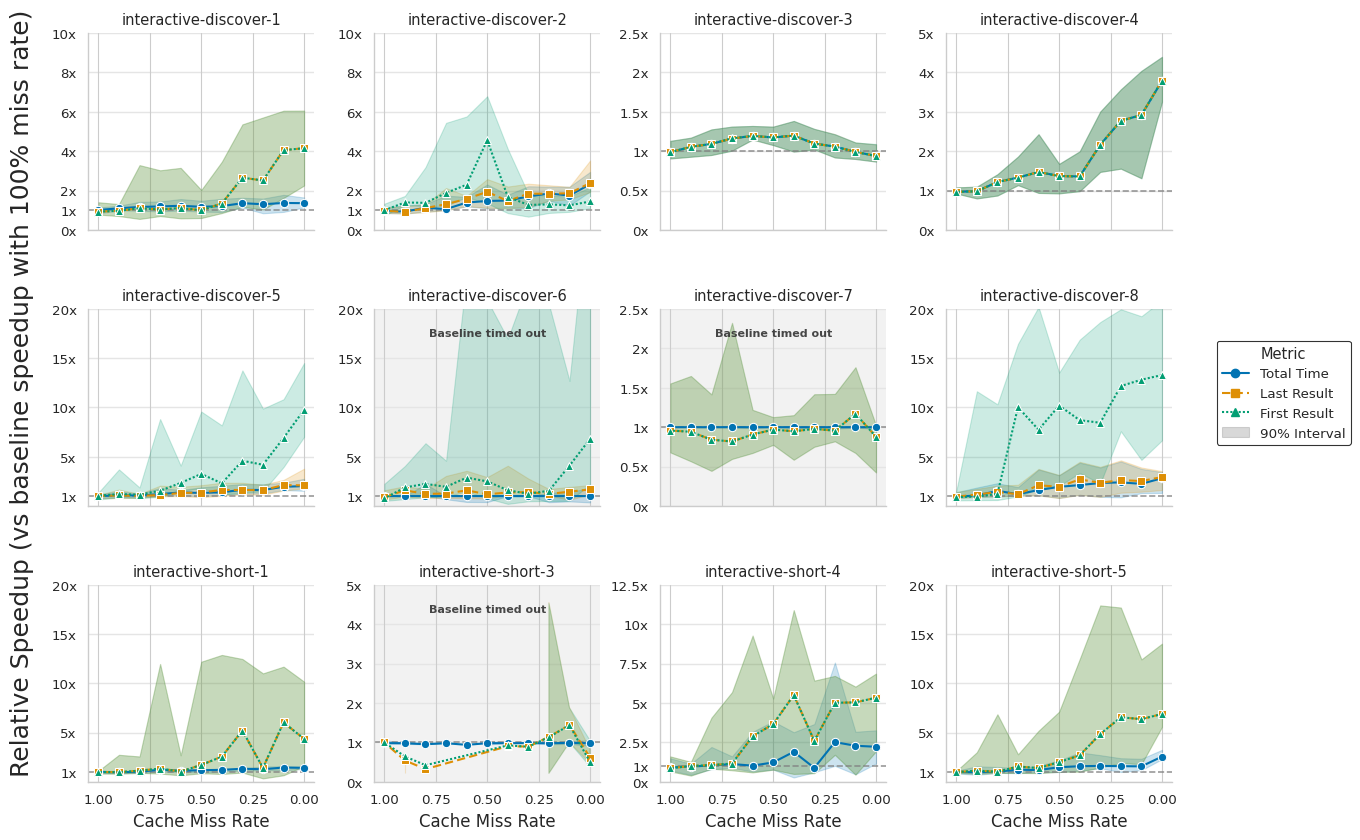

In [7]:
from pathlib import Path
import numpy as np
from matplotlib import ticker
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def create_trellis_plot_scatter(df):
    sns.set_theme(style="whitegrid")

    # Plot the mean trend lines
    g = sns.relplot(
        data=df,
        x="missrate",
        y="Speedup",
        hue="Metric",
        style="Metric",
        col="template",
        col_wrap=5,
        kind="line",
        marker="o",
        errorbar=None,  # Remove error bands
        estimator="mean",
        height=3,
        aspect=1,
        facet_kws={'sharey': False, 'sharex': True}
    )

    # Map raw data scatter points onto the same grid
    g.map_dataframe(
        sns.scatterplot,
        x="missrate",
        y="Speedup",
        hue="Metric",
        alpha=0.4,      # Make points semi-transparent
        legend=False    # Prevent duplicate legend entries
    )

    # Invert X axis to range from 1 to 0
    g.set(xlim=(1.05, -0.05))
    g.set_axis_labels("Cache Missrate", "")
    g.set_titles(col_template="{col_name}")

    for ax in g.axes.flat:
        title = ax.get_title()

        if "(Timeout Baseline)" in title:
            ax.set_title(title.replace(" (Timeout Baseline)", ""))
            ax.set_facecolor('#fff4f4')
            ax.text(0.5, 0.9, "Baseline timed out",
                    transform=ax.transAxes, ha='center', va='top',
                    fontsize=8, color='crimson', alpha=0.7)

        ax.axhline(1.0, color='gray', linestyle='--', linewidth=1, zorder=0)

        ylim = ax.get_ylim()
        new_top = max(ylim[1], 2.5)
        ax.set_ylim(bottom=0, top=new_top)

        ylim = ax.get_ylim()
        ticks = ax.get_yticks()

        if len(ticks) > 1:
            step = ticks[1] - ticks[0]
            if step > 0:
                min_tick = 1.0 - np.ceil((1.0 - ylim[0]) / step) * step
                max_tick = 1.0 + np.ceil((ylim[1] - 1.0) / step) * step

                new_ticks = np.arange(min_tick, max_tick + step / 2, step)
                new_ticks = new_ticks[new_ticks >= 0]
                ax.set_yticks(new_ticks)

        ax.set_ylim(bottom=0, top=ylim[1])
        ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: f'{y:g}x'))

    g.figure.suptitle("Theoretical Indexed Cache Performance by Template")
    g.figure.subplots_adjust(top=0.9, left=0.06)
    g.figure.text(0.01, 0.5, "Relative Speedup (vs baseline missrate)",
               va='center', ha='center', rotation='vertical', fontsize=12)

    plt.savefig("cache_performance_trellis_scatter.png", dpi=300, bbox_inches='tight')
    plt.show()



def create_trellis_plot_minmax(df, save_location="cache_performance_trellis_academic.pdf"):
    sns.set_theme(style="whitegrid", context="paper", font_scale=1.1)

    col_wrap = 4

    g = sns.relplot(
        data=df,
        x="missrate",
        y="Speedup",
        hue="Metric",
        style="Metric",
        col="template",
        col_wrap=col_wrap,
        kind="line",
        markers=["o", "s", "^"],
        dashes=[(None, None), (4, 2), (1, 1)],
        palette="colorblind",
        linewidth=1.5,
        markersize=6,
        errorbar=("pi", 90),
        height=3,
        aspect=1,
        facet_kws={'sharey': False, 'sharex': True},
        estimator='median'
    )

    g.set(xlim=(1.05, -0.05))
    g.set_axis_labels("Cache Miss Rate", "", fontsize=12)
    g.set_titles(col_template="{col_name}", fontsize=16)

    for ax in g.axes.flat:
        title = ax.get_title()

        if "(Timeout Baseline)" in title:
            ax.set_title(title.replace(" (Timeout Baseline)", ""))
            ax.set_facecolor('#f2f2f2')
            ax.text(0.5, 0.9, "Baseline timed out",
                    transform=ax.transAxes, ha='center', va='top',
                    fontsize=8, color='#333333', fontweight='bold', alpha=0.9)

        # Proportional Grid Alignment with an upper bound cap
        data_max = ax.get_ylim()[1]
        data_max = min(max(data_max, 2.5), 20.0)

        n_bins = 5
        raw_step = data_max / n_bins

        mag = np.floor(np.log10(raw_step))
        mag_pow = 10 ** mag
        norm_step = raw_step / mag_pow

        if norm_step <= 1.0:
            nice_norm = 1.0
        elif norm_step <= 2.0:
            nice_norm = 2.0
        elif norm_step <= 2.5:
            nice_norm = 2.5
        elif norm_step <= 5.0:
            nice_norm = 5.0
        else:
            nice_norm = 10.0

        step = nice_norm * mag_pow

        # Ensure max value bounds to the 20x limit without breaking tick distribution
        max_val = min(step * n_bins, 20.0)

        # Calculate ticks strictly within the bounded maximum
        base_ticks = [step * i for i in range(n_bins + 1) if (step * i) <= max_val]

        if max_val not in base_ticks and max_val == 20.0:
             base_ticks.append(20.0)

        # Disable auto y-grid to prevent the 1.0 tick from spawning a misaligned grid line
        ax.yaxis.grid(False)

        # Manually draw the proportional background grid lines
        for tick_val in base_ticks:
            ax.axhline(tick_val, color='#e5e5e5', linewidth=1, zorder=0)

        # Draw the 1.0 baseline explicitly (dashed to differentiate from grid)
        ax.axhline(1.0, color='gray', linestyle='--', linewidth=1.2, alpha=0.8, zorder=1)

        ticks = set(base_ticks)
        ticks.add(1.0)

        ax.set_ylim(bottom=0, top=max_val)
        ax.set_yticks(sorted(list(ticks)))

        # Formatter: Hide any label (including 0x) that overlaps with the 1x baseline
        def make_formatter(current_step):
            def fmt(y, pos):
                if y != 1.0 and abs(y - 1.0) < current_step * 0.35:
                    return ""
                return f'{y:g}x'
            return ticker.FuncFormatter(fmt)

        ax.yaxis.set_major_formatter(make_formatter(step))

    # Extract legend
    if g.legend:
        g.legend.remove()

    handles, labels = g.axes.flat[0].get_legend_handles_labels()
    minmax_patch = mpatches.Patch(color='gray', alpha=0.3)
    handles.append(minmax_patch)
    labels.append('90% Interval')

    g.figure.legend(handles=handles, labels=labels,
                    loc='center right', bbox_to_anchor=(1.02, 0.5),
                    title="Metric", frameon=True, edgecolor='black')

    # Increase hspace to prevent X-axis labels from overlapping bottom row titles
    g.figure.subplots_adjust(top=0.9, left=0.06, right=0.88, hspace=0.4)

    g.figure.text(0.01, 0.5, "Relative Speedup (vs baseline speedup with 100% miss rate)",
               va='center', ha='center', rotation='vertical', fontsize=18)

    # Resolve directory and save using the exact provided path
    save_path = Path(save_location)
    save_path.parent.mkdir(parents=True, exist_ok=True)

    plt.savefig(save_path, bbox_inches='tight')
    plt.show()


if __name__ == "__main__":
    df_results = load_and_process_data("../data/data-synth-hitrate")
    if not df_results.empty:
        # create_trellis_plot_scatter(df_results)
        create_trellis_plot_minmax(df_results, save_location="../output/synth_hitrate_figures/cache-synth-hitrate.pdf")
    else:
        print("No valid data found after filtering errors.")

    df_results_query_cache = load_and_process_data("../data/data-synth-hitrate-query-cache",
                                                   file_pattern="query-results-raw-query-cache-hitrate-*.json",
                                                   )
    if not df_results.empty:
        # create_trellis_plot_scatter(df_results)
        create_trellis_plot_minmax(df_results_query_cache, save_location="../output/synth_hitrate_figures/query-cache-synth-hitrate.pdf")

